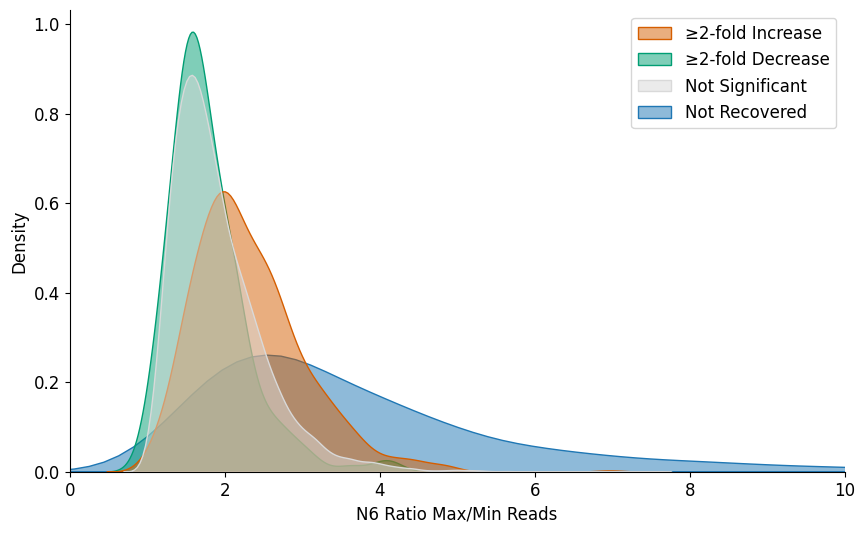

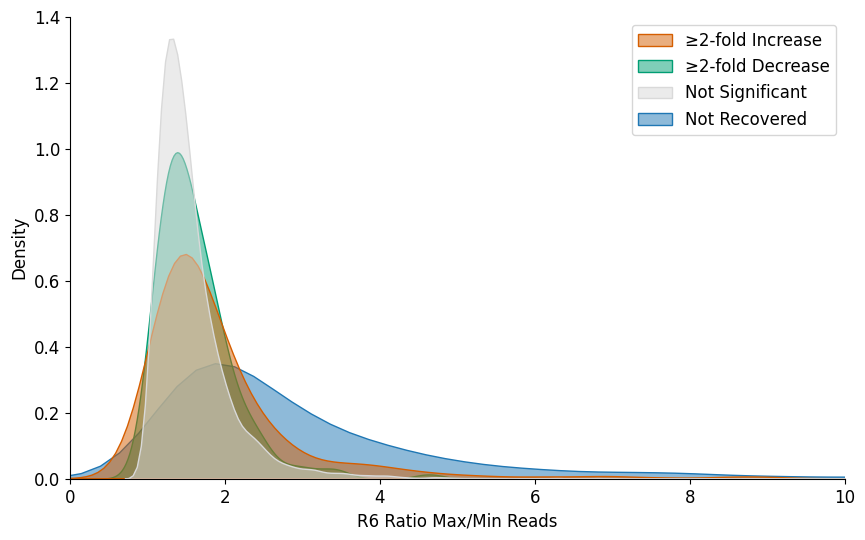

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator


results_df = pd.read_csv("../data/12k_all_results.csv")


results_df["n6_minmax_ratio"] = results_df[["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3"]].max(axis=1) / results_df[["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3"]].min(axis=1)
results_df["r6_minmax_ratio"] = results_df[["leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"]].max(axis=1) / results_df[["leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"]].min(axis=1)

results_df = results_df.sort_values("r6_minmax_ratio", ascending=False)

palette = {
    "Not Recovered": "#1f77b4",
    "Up": "#D55E00",
    "Down": "#009E73",
    "Not Sig": "#D9D9D9",
}
legend_order = ["Up", "Down", "Not Sig", "Not Recovered"]
# rename to: "≥2-fold Increase", "≥2-fold Decrease", "Not Significant", "Not Recovered"
legend_labels = ["≥2-fold Increase", "≥2-fold Decrease", "Not Significant", "Not Recovered"]

# plot the distribution of the minmax ratios for N6 and R6 (ignoring the inf values)
# make it a kde plot, one for each fourclass, all overlaid
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(data=results_df[results_df["n6_minmax_ratio"] != np.inf], x="n6_minmax_ratio", hue="fourclass", fill=True, common_norm=False, alpha=0.5, palette=palette, hue_order=["Not Sig", "Up", "Down", "Not Recovered"])
plt.xlim(0, 10)
plt.xlabel("N6 Ratio Max/Min Reads", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

# reorder and rename legend
leg = ax.get_legend()
handle_by_label = dict(zip([t.get_text() for t in leg.get_texts()], leg.legend_handles))
ax.legend([handle_by_label[l] for l in legend_order], legend_labels, fontsize=12, title_fontsize=12)

plt.savefig("../results/analysis/n6_minmax_ratio_kde.png", dpi=300, bbox_inches="tight")

plt.figure(figsize=(10, 6))
ax = sns.kdeplot(data=results_df[results_df["r6_minmax_ratio"] != np.inf], x="r6_minmax_ratio", hue="fourclass", fill=True, common_norm=False, alpha=0.5, palette=palette, hue_order=["Not Sig", "Up", "Down", "Not Recovered"])
plt.xlim(0, 10)
plt.xlabel("R6 Ratio Max/Min Reads", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

leg = ax.get_legend()
handle_by_label = dict(zip([t.get_text() for t in leg.get_texts()], leg.legend_handles))
ax.legend([handle_by_label[l] for l in legend_order], legend_labels, fontsize=12, title_fontsize=12)

plt.savefig("../results/analysis/r6_minmax_ratio_kde.png", dpi=300, bbox_inches="tight")


In [8]:
import os
import matplotlib.patches as mpatches
from sklearn.metrics import r2_score

os.makedirs("../results/jackpot_plots", exist_ok=True)

conditions = {
    "N6": ["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3"],
    "R6": ["leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"],
}
pairs = [(0, 1), (1, 2), (0, 2)]
pair_labels = [("1", "2"), ("2", "3"), ("1", "3")]

fourclass_order = ["Up", "Down", "Not Sig", "Not Recovered"]
fourclass_display = {
    "Up": "≥2-fold Increase",
    "Down": "≥2-fold Decrease",
    "Not Sig": "Not Significant",
    "Not Recovered": "Not Recovered",
}
draw_order = ["Not Sig", "Not Recovered", "Down", "Up"]

for cond, cols in conditions.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (i, j), (l1, l2) in zip(axes, pairs, pair_labels):
        for fc in draw_order:
            sub = results_df[results_df["fourclass"] == fc]
            ax.scatter(sub[cols[i]], sub[cols[j]],
                       color=palette[fc], alpha=0.3, s=3, rasterized=True)

        # y=x reference line across the data range
        all_vals = results_df[[cols[i], cols[j]]].values.flatten()
        all_vals = all_vals[all_vals > 0]
        lim = (all_vals.min() * 0.9, all_vals.max() * 1.1)
        ax.plot(lim, lim, color="black", linewidth=0.8, linestyle="--", zorder=5)
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        # R² for y=x in log10 space (zeros excluded)
        mask = (results_df[cols[i]] > 0) & (results_df[cols[j]] > 0)
        lx = np.log10(results_df.loc[mask, cols[i]])
        ly = np.log10(results_df.loc[mask, cols[j]])
        r2 = r2_score(ly, lx)
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
                fontsize=11, va="top", ha="left")

        ax.set_xlabel(f"{cond}.{l1} Reads", fontsize=12)
        ax.set_ylabel(f"{cond}.{l2} Reads", fontsize=12)
        ax.set_xscale("log")
        ax.set_yscale("log")
        sns.despine(ax=ax)

    legend_patches = [mpatches.Patch(color=palette[fc], label=fourclass_display[fc]) for fc in fourclass_order]
    # remove legend frame and set it above
    fig.legend(handles=legend_patches, fontsize=11, title_fontsize=12, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))
    plt.tight_layout()
    plt.savefig(f"../results/jackpot_plots/{cond}_all_scatter.png", dpi=300, bbox_inches="tight")
    plt.close()
